In [1]:
!git clone https://github.com/OmmkarKhandai/disaster-predictor-ai.git

Cloning into 'disaster-predictor-ai'...
remote: Enumerating objects: 5525, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 5525 (delta 22), reused 29 (delta 9), pack-reused 5409 (from 1)
Receiving objects: 100% (5525/5525), 131.70 MiB | 46.89 MiB/s, done.
Resolving deltas: 100% (128/128), done.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

df_cyclone = pd.read_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_dataset.csv")

print("Shape:", df_cyclone.shape)
print("\nMissing Values:")
print(df_cyclone.isnull().sum())
print("\nDuplicate Rows:", df_cyclone.duplicated().sum())
print("\nData Types:")
print(df_cyclone.dtypes)
print("\nBasic Stats:")
print(df_cyclone.describe().round(2))

Shape: (2000, 10)

Missing Values:
Sea_Surface_Temperature     0
Atmospheric_Pressure        0
Humidity                    0
Wind_Shear                  0
Vorticity                   0
Latitude                    0
Ocean_Depth                 0
Proximity_to_Coastline      0
Pre_existing_Disturbance    0
Cyclone                     0
dtype: int64

Duplicate Rows: 0

Data Types:
Sea_Surface_Temperature     float64
Atmospheric_Pressure        float64
Humidity                    float64
Wind_Shear                  float64
Vorticity                   float64
Latitude                    float64
Ocean_Depth                 float64
Proximity_to_Coastline      float64
Pre_existing_Disturbance      int64
Cyclone                       int64
dtype: object

Basic Stats:
       Sea_Surface_Temperature  Atmospheric_Pressure  Humidity  Wind_Shear  \
count                  2000.00               2000.00   2000.00     2000.00   
mean                     26.01               1003.39     67.20       16.13  

In [5]:
import pandas as pd

df_cyclone = pd.read_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_dataset.csv")

df_cyclone = df_cyclone.drop(columns=["Vorticity"])
print("Step 1: Dropped Vorticity")
print("Step 2: Missing Values:", df_cyclone.isnull().sum().sum())
print("Step 3: Duplicates:", df_cyclone.duplicated().sum())
print("\n=== OUTLIER CHECK ===")
for col in df_cyclone.drop("Cyclone", axis=1).columns:
    Q1  = df_cyclone[col].quantile(0.25)
    Q3  = df_cyclone[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_cyclone[col] < Q1 - 1.5*IQR) |
                (df_cyclone[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:30s} → Outliers: {outliers}")
print("Shape:", df_cyclone.shape)
df_cyclone.to_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_cleaned.csv", index=False)
print("Cleaned file saved!")

Step 1: Dropped Vorticity
Step 2: Missing Values: 0
Step 3: Duplicates: 0

=== OUTLIER CHECK ===
Sea_Surface_Temperature        → Outliers: 0
Atmospheric_Pressure           → Outliers: 0
Humidity                       → Outliers: 0
Wind_Shear                     → Outliers: 0
Latitude                       → Outliers: 0
Ocean_Depth                    → Outliers: 0
Proximity_to_Coastline         → Outliers: 0
Pre_existing_Disturbance       → Outliers: 0
Shape: (2000, 9)
Cleaned file saved!


/tmp/ipykernel_1727/2437233634.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cyclone", y=col,
/tmp/ipykernel_1727/2437233634.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Cyclone", "Cyclone"], fontsize=8)
/tmp/ipykernel_1727/2437233634.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Cyclone", y=col,
/tmp/ipykernel_1727/2437233634.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No Cyclone", "Cyclone"], fontsize=8)
/tmp/ipykernel_1727/

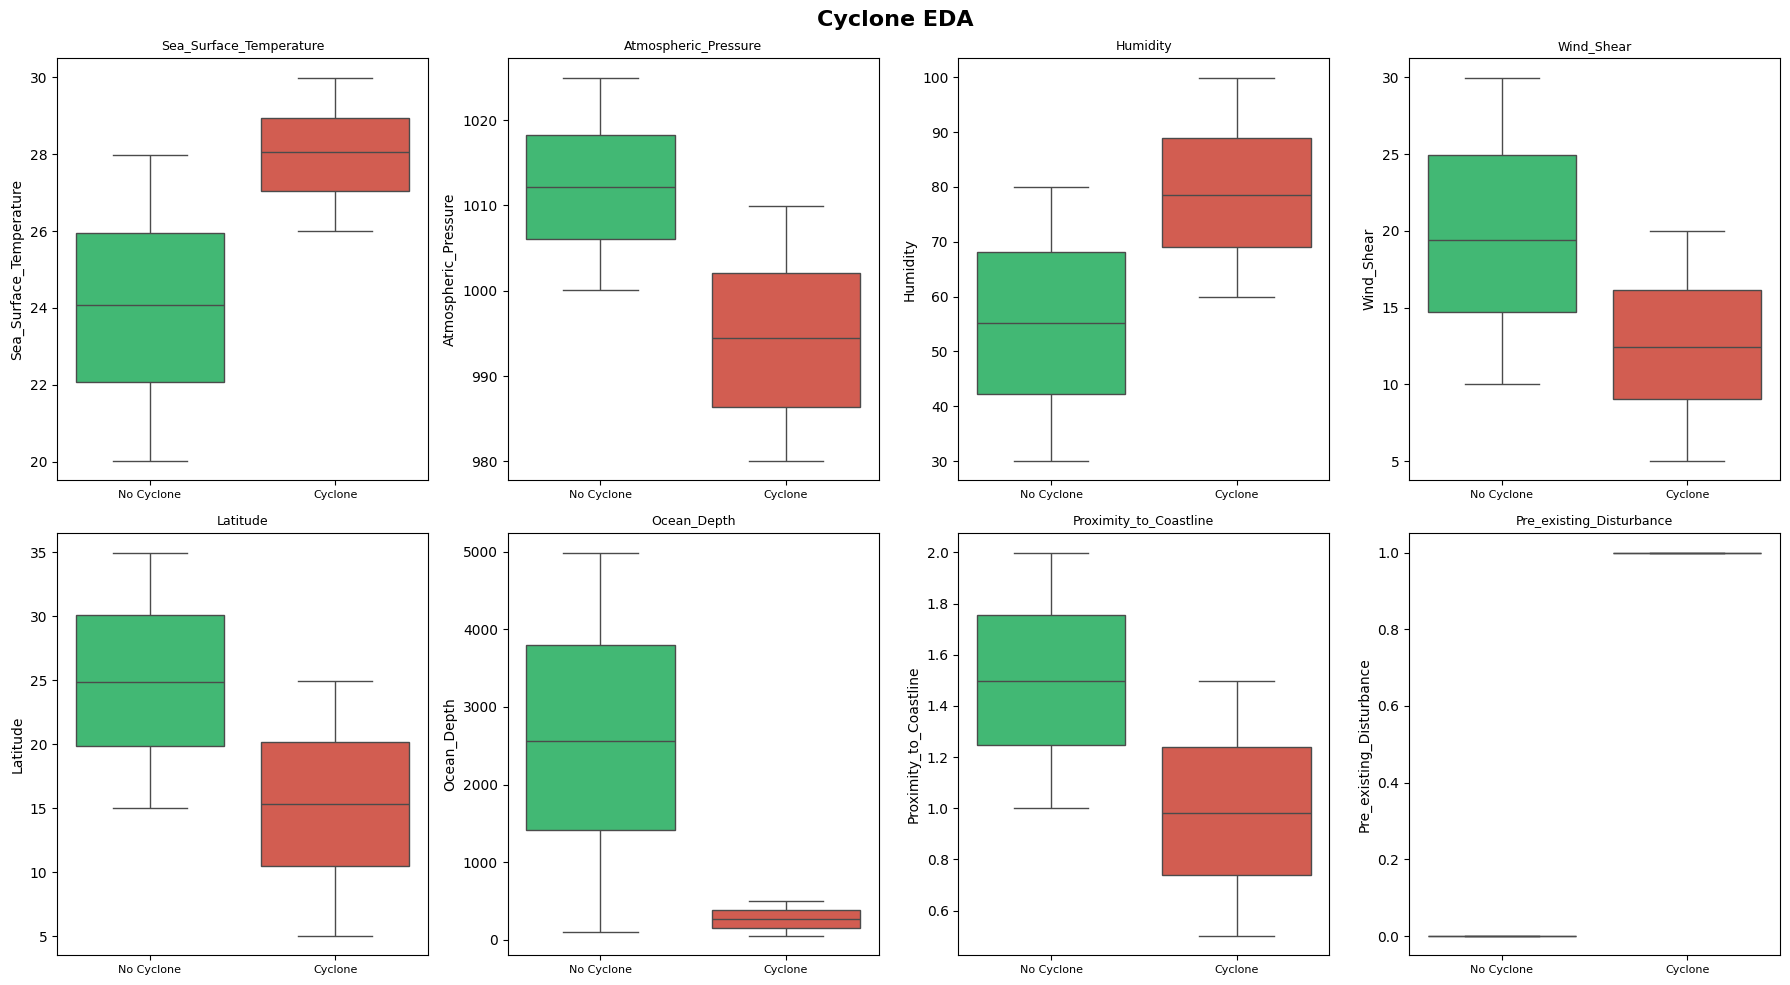

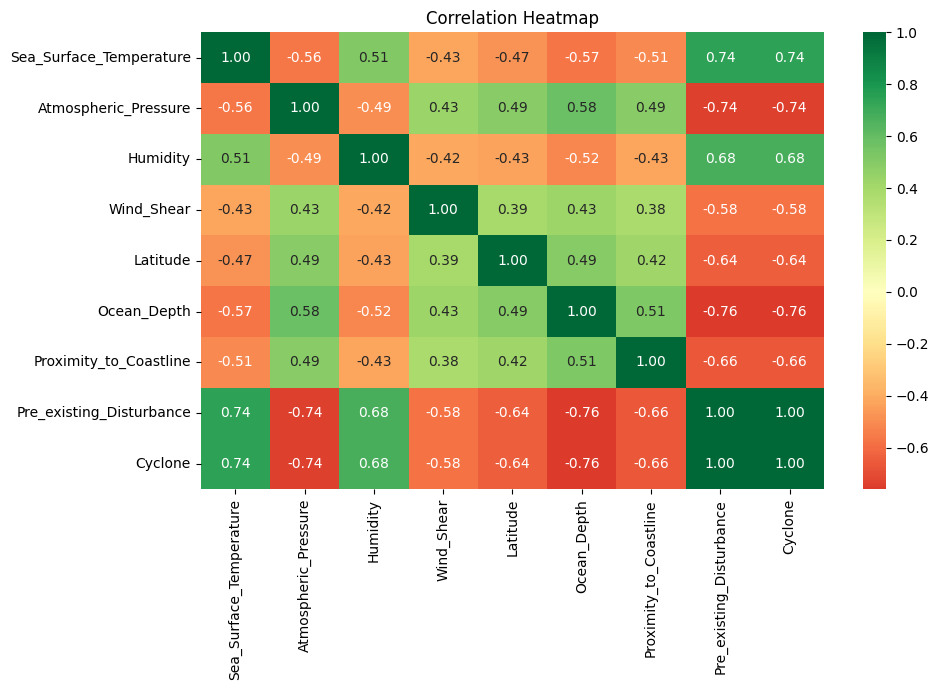

Sea_Surface_Temperature        → No Cyclone: 24.01 | Cyclone: 28.01 | Diff: +4.00
Atmospheric_Pressure           → No Cyclone: 1012.33 | Cyclone: 994.45 | Diff: -17.88
Humidity                       → No Cyclone: 55.24 | Cyclone: 79.17 | Diff: +23.94
Wind_Shear                     → No Cyclone: 19.71 | Cyclone: 12.55 | Diff: -7.16
Latitude                       → No Cyclone: 24.89 | Cyclone: 15.22 | Diff: -9.67
Ocean_Depth                    → No Cyclone: 2592.75 | Cyclone: 273.34 | Diff: -2319.41
Proximity_to_Coastline         → No Cyclone: 1.50 | Cyclone: 0.99 | Diff: -0.51
Pre_existing_Disturbance       → No Cyclone: 0.00 | Cyclone: 1.00 | Diff: +1.00


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_cleaned.csv")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle("Cyclone EDA", fontsize=16, fontweight="bold")

cols = ["Sea_Surface_Temperature", "Atmospheric_Pressure",
        "Humidity", "Wind_Shear", "Latitude",
        "Ocean_Depth", "Proximity_to_Coastline", "Pre_existing_Disturbance"]

for i, col in enumerate(cols):
    ax = axes[i//4][i%4]
    sns.boxplot(data=df, x="Cyclone", y=col,
                palette=["#2ecc71", "#e74c3c"], ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xticklabels(["No Cyclone", "Cyclone"], fontsize=8)
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig("/content/disaster-predictor-ai/eda_cyclone.png")
plt.show()

plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("/content/disaster-predictor-ai/eda_cyclone_corr.png")
plt.show()
for col in cols:
    no_cy = df[df["Cyclone"]==0][col].mean()
    cy    = df[df["Cyclone"]==1][col].mean()
    diff  = cy - no_cy
    print(f"{col:30s} → No Cyclone: {no_cy:.2f} | Cyclone: {cy:.2f} | Diff: {diff:+.2f}")

In [9]:
import pandas as pd

df = pd.read_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_cleaned.csv")
df["SST_Pressure"]    = df["Sea_Surface_Temperature"] * (1000 / df["Atmospheric_Pressure"])
df["Humid_WindShear"] = df["Humidity"] / df["Wind_Shear"]
df["High_Risk_Flag"]  = ((df["Sea_Surface_Temperature"] > 26.5) &
                          (df["Atmospheric_Pressure"] < 1000)).astype(int)
print("Feature Engineering done!")
print("New Shape:", df.shape)
print("\nNew Columns:", df.columns.tolist())
print("\nNew Features Preview:")
print(df[["SST_Pressure", "Humid_WindShear", "High_Risk_Flag"]].head(10))
df.to_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_featured.csv", index=False)
print("\n Featured file saved!")

Feature Engineering done!
New Shape: (2000, 12)

New Columns: ['Sea_Surface_Temperature', 'Atmospheric_Pressure', 'Humidity', 'Wind_Shear', 'Latitude', 'Ocean_Depth', 'Proximity_to_Coastline', 'Pre_existing_Disturbance', 'Cyclone', 'SST_Pressure', 'Humid_WindShear', 'High_Risk_Flag']

New Features Preview:
   SST_Pressure  Humid_WindShear  High_Risk_Flag
0     27.265817         6.386305               0
1     28.369220         3.111386               0
2     27.333335         8.248740               1
3     27.725707         5.347612               0
4     26.039739         5.758818               0
5     26.625131         3.292713               0
6     28.600239         5.941146               1
7     26.731432         6.256009               0
8     27.224991         3.853528               1
9     25.906446         5.539611               0

 Featured file saved!


In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/disaster-predictor-ai/data/cyclone/cyclone_featured.csv")

X = df.drop("Cyclone", axis=1)
y = df["Cyclone"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train/Test Split done!")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nTrain Target Distribution:\n{y_train.value_counts()}")
print(f"\nTest Target Distribution:\n{y_test.value_counts()}")

Train/Test Split done!
X_train: (1600, 11)
X_test:  (400, 11)

Train Target Distribution:
Cyclone
1    800
0    800
Name: count, dtype: int64

Test Target Distribution:
Cyclone
0    200
1    200
Name: count, dtype: int64


In [12]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
models = {
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=8,
                                                   min_samples_leaf=5, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(max_depth=4, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
}
best_score = 0
best_name  = ""
best_model = None

for name, model in models.items():
    Xtr = X_train_sc if name == "Logistic Regression" else X_train
    Xte = X_test_sc  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train)
    train_acc = model.score(Xtr, y_train)
    test_acc  = model.score(Xte, y_test)
    print(f"{name:25s} → Train: {train_acc:.3f} | Test: {test_acc:.3f}")

    if test_acc > best_score:
        best_score = test_acc
        best_name  = name
        best_model = model

print(f"\nBest Model: {best_name} (Test: {best_score:.3f})")
Xte = X_test_sc if best_name == "Logistic Regression" else X_test
print(classification_report(y_test, best_model.predict(Xte),
      target_names=["No Cyclone", "Cyclone"]))

Random Forest             → Train: 1.000 | Test: 1.000
Gradient Boosting         → Train: 1.000 | Test: 1.000
Logistic Regression       → Train: 1.000 | Test: 1.000

Best Model: Random Forest (Test: 1.000)
              precision    recall  f1-score   support

  No Cyclone       1.00      1.00      1.00       200
     Cyclone       1.00      1.00      1.00       200

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [13]:
import joblib, os

os.makedirs("/content/disaster-predictor-ai/models", exist_ok=True)
joblib.dump(best_model, "/content/disaster-predictor-ai/models/cyclone_model.pkl")
joblib.dump(scaler,     "/content/disaster-predictor-ai/models/cyclone_scaler.pkl")
joblib.dump(list(X.columns), "/content/disaster-predictor-ai/models/cyclone_features.pkl")

print("Cyclone model saved!")
print("Files:", os.listdir("/content/disaster-predictor-ai/models"))

Cyclone model saved!
Files: ['cyclone_features.pkl', 'flood_model.pkl', 'README.md', 'cyclone_cnn_model.keras', 'earthquake_features.pkl', 'cyclone_model.pkl', 'earthquake_le_region.pkl', 'cyclone_scaler.pkl', 'flood_features.pkl', 'earthquake_model.pkl', 'landslide_features.pkl', 'landslide_model.pkl']


In [ ]:
import os

cyclone_path    = "/content/disaster-predictor-ai/data/cyclone/images/cyclone"
no_cyclone_path = "/content/disaster-predictor-ai/data/cyclone/images/no_cyclone"

cyclone_imgs    = os.listdir(cyclone_path)
no_cyclone_imgs = os.listdir(no_cyclone_path)

print(f"Cyclone images:    {len(cyclone_imgs)}")
print(f"No Cyclone images: {len(no_cyclone_imgs)}")
print(f"\nSample cyclone files:    {cyclone_imgs[:5]}")
print(f"Sample no_cyclone files: {no_cyclone_imgs[:5]}")

Cyclone images:    2612
No Cyclone images: 2516

Sample cyclone files:    ['200710L_2007092118.png', '200815L_2008101615.png', '200712E_2007092118.png', '200621W_2006101606.png', '201117L_2011092512.png']
Sample no_cyclone files: ['train_19442.jpg', 'SeaLake_2742.jpg', 'desert(963).jpg', 'SeaLake_1522.jpg', 'desert(407).jpg']


Sample image sizes: [(128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128), (128, 128)]
Total cyclone: 2612
Total no_cyclone: 2516


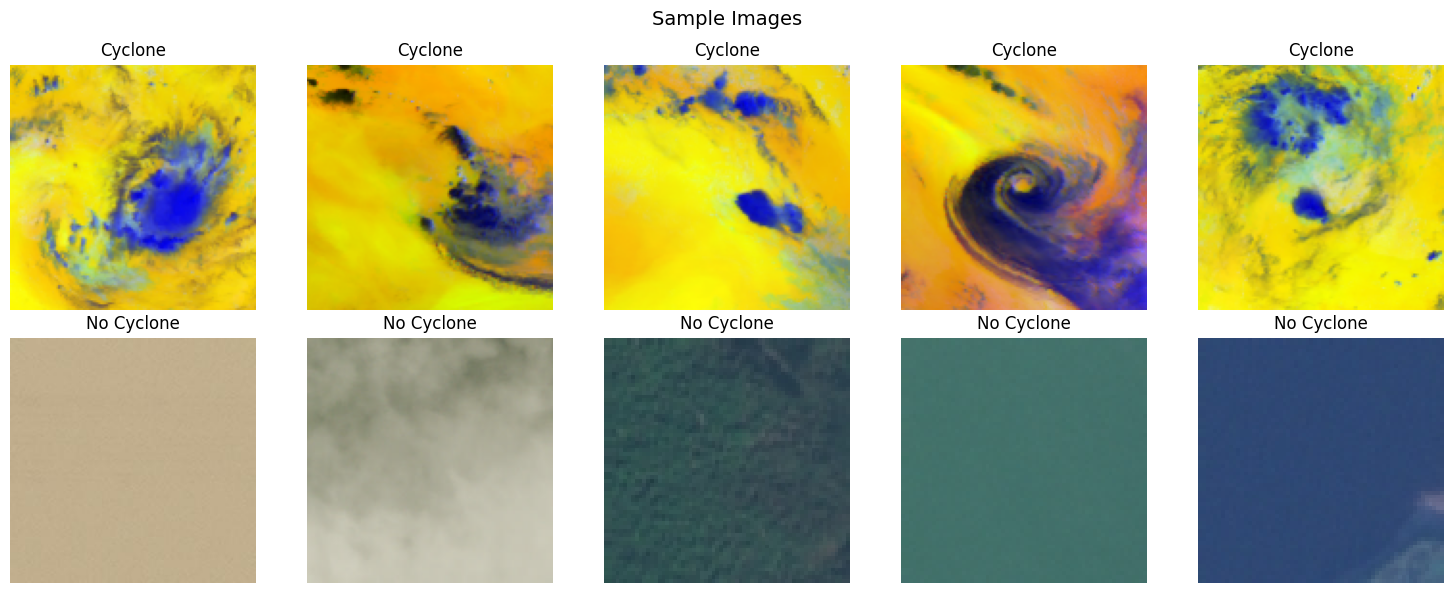

In [14]:
import os
from PIL import Image
import numpy as np

cyclone_dir    = "/content/disaster-predictor-ai/data/cyclone/images/cyclone"
no_cyclone_dir = "/content/disaster-predictor-ai/data/cyclone/images/no_cyclone"

sizes = []
for f in os.listdir(cyclone_dir)[:20]:
    if f.endswith(('.jpg','.jpeg','.png')):
        img = Image.open(os.path.join(cyclone_dir, f))
        sizes.append(img.size)

print("Sample image sizes:", sizes[:10])
print("Total cyclone:",    len(os.listdir(cyclone_dir)))
print("Total no_cyclone:", len(os.listdir(no_cyclone_dir)))
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images", fontsize=14)

cy_files    = os.listdir(cyclone_dir)[:5]
nocy_files  = os.listdir(no_cyclone_dir)[:5]

for i, f in enumerate(cy_files):
    img = Image.open(os.path.join(cyclone_dir, f))
    axes[0][i].imshow(img)
    axes[0][i].set_title("Cyclone")
    axes[0][i].axis("off")

for i, f in enumerate(nocy_files):
    img = Image.open(os.path.join(no_cyclone_dir, f))
    axes[1][i].imshow(img)
    axes[1][i].set_title("No Cyclone")
    axes[1][i].axis("off")

plt.tight_layout()
plt.show()


Found 4100 images belonging to 2 classes.
Found 1025 images belonging to 2 classes.
Train: 4100 | Val: 1025
Classes: {'cyclone': 0, 'no_cyclone': 1}
Epoch 1/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 306s 5s/step - accuracy: 0.9920 - loss: 0.0229 - val_accuracy: 0.4907 - val_loss: 1.5477 - learning_rate: 0.0010
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 326s 5s/step - accuracy: 1.0000 - loss: 5.7173e-04 - val_accuracy: 0.4907 - val_loss: 2.6808 - learning_rate: 0.0010
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 435s 7s/step - accuracy: 1.0000 - loss: 4.9178e-04 - val_accuracy: 0.4907 - val_loss: 3.7521 - learning_rate: 0.0010
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9996 - loss: 0.0011
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
65/65 ━━━━━━━━━━━━━━━━━━━━ 330s 5s/step - accuracy: 0.9993 - loss: 0.0017 - val_accuracy: 0.4907 - val_loss: 3.4351 - learning_rate: 0.0010
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 270s 4s/step - accuracy: 1.0000 - loss: 3.1709e-04 - 

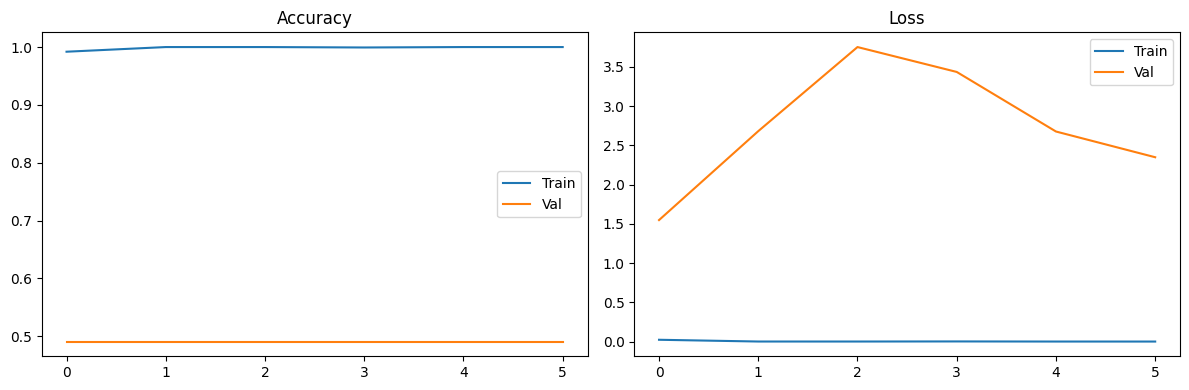


CNN saved!
Train Accuracy: 1.000
Val Accuracy:   0.491


In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

IMG_SIZE   = (128, 128)
BATCH_SIZE = 64
EPOCHS     = 30
DATA_DIR   = "/content/disaster-predictor-ai/data/cyclone/images"

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
val_datagen   = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", subset="training", seed=42)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="binary", subset="validation", seed=42)

print("Train:", train_gen.samples, "| Val:", val_gen.samples)
print("Classes:", train_gen.class_indices)

model = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_gen, validation_data=val_gen, epochs=EPOCHS,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, verbose=1)
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Val")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("/content/disaster-predictor-ai/cyclone_cnn_fixed.png")
plt.show()

model.save("/content/disaster-predictor-ai/models/cyclone_cnn_model.keras")
print(f"\nCNN saved!")
print(f"Train Accuracy: {max(history.history['accuracy']):.3f}")
print(f"Val Accuracy:   {max(history.history['val_accuracy']):.3f}")

In [16]:
import os
os.chdir("/content/disaster-predictor-ai")

!git add .
!git commit -m "Add cyclone CSV model, scaler and features"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@aa1417ace5be.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [17]:
import pandas as pd

df_flood = pd.read_csv("/content/disaster-predictor-ai/data/flood/flood (3).csv")
print("Shape:", df_flood.shape)
print("\n", df_flood.head(10))
print("\nColumns:", df_flood.columns.tolist())

Shape: (50000, 21)

    MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0                 3                   8                6              6   
1                 8                   4                5              7   
2                 3                  10                4              1   
3                 4                   4                2              7   
4                 3                   7                5              2   
5                 6                   6                6              4   
6                 6                   7                4              5   
7                 7                   3                5              5   
8                 6                   3                5              4   
9                 4                   3                5              6   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0             4              4            6          2                  

=== MISSING VALUES ===
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
FloodProbability                   0
dtype: int64

=== DUPLICATES ===
Duplicate rows: 0

=== TARGET STATS ===
count    50000.000000
mean         0.499660
std          0.050034
min          0.285000
25%          0.465000
50%          0.50

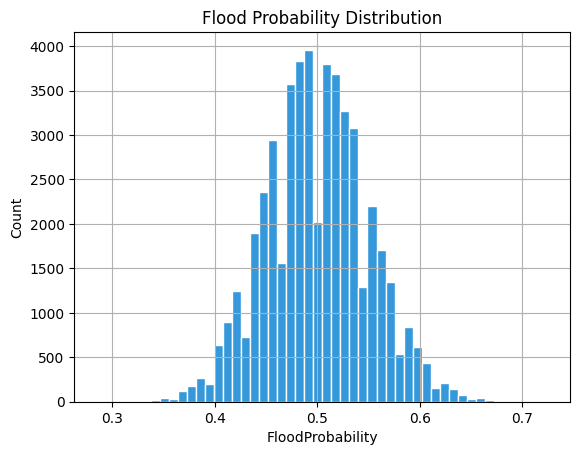

In [18]:
import pandas as pd

df_flood = pd.read_csv("/content/disaster-predictor-ai/data/flood/flood (3).csv")

print("=== MISSING VALUES ===")
print(df_flood.isnull().sum())

print("\n=== DUPLICATES ===")
print("Duplicate rows:", df_flood.duplicated().sum())

print("\n=== TARGET STATS ===")
print(df_flood["FloodProbability"].describe())

print("\n=== TARGET DISTRIBUTION ===")
import matplotlib.pyplot as plt
df_flood["FloodProbability"].hist(bins=50, color="#3498db", edgecolor="white")
plt.title("Flood Probability Distribution")
plt.xlabel("FloodProbability")
plt.ylabel("Count")
plt.show()

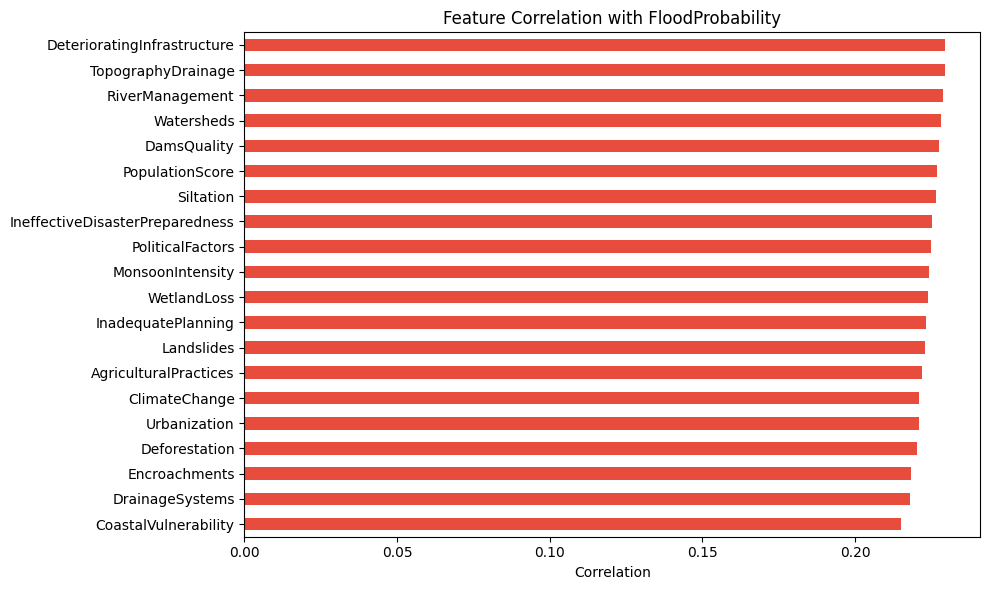

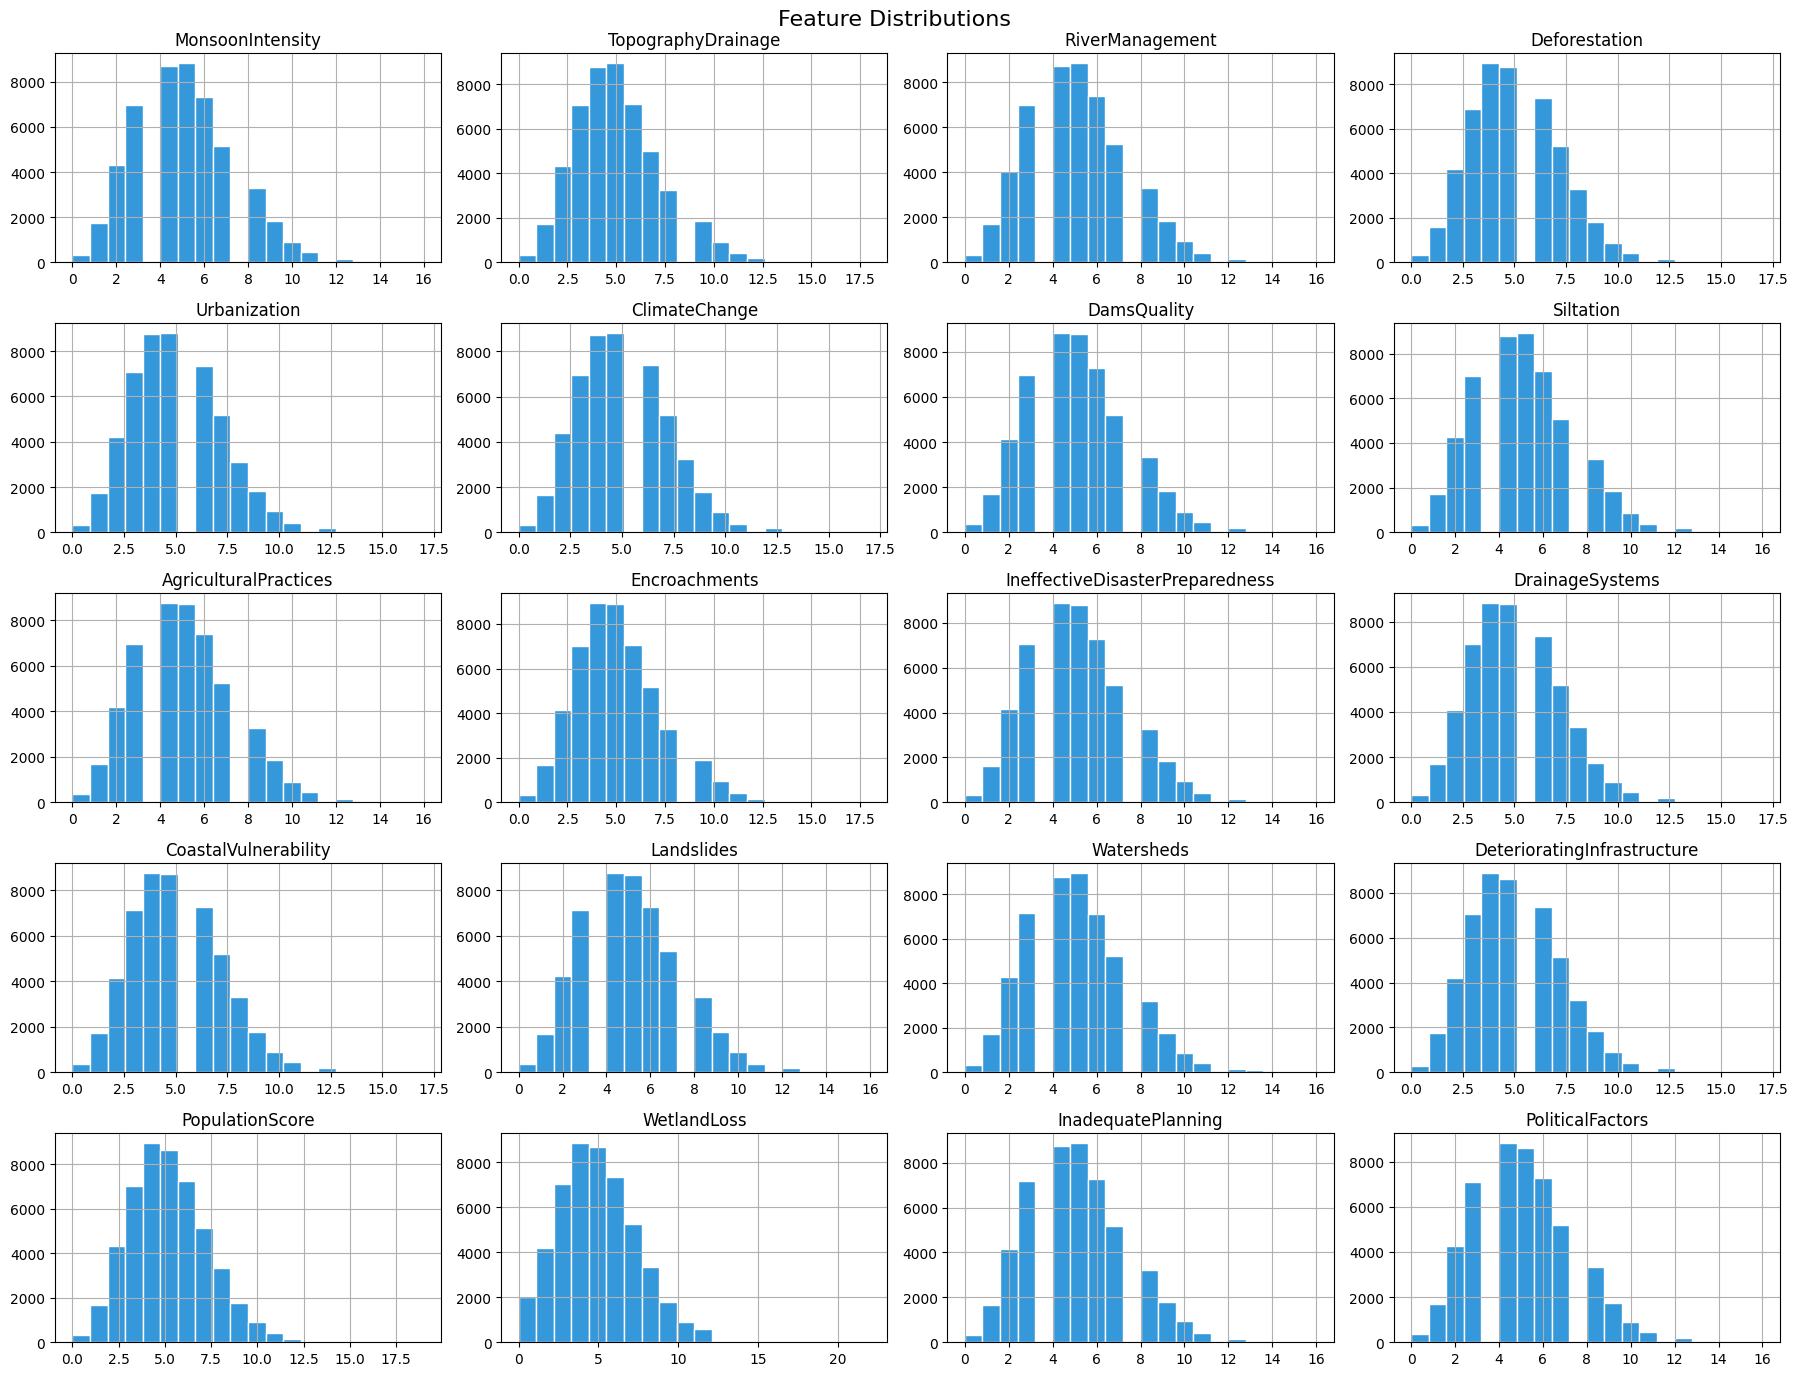

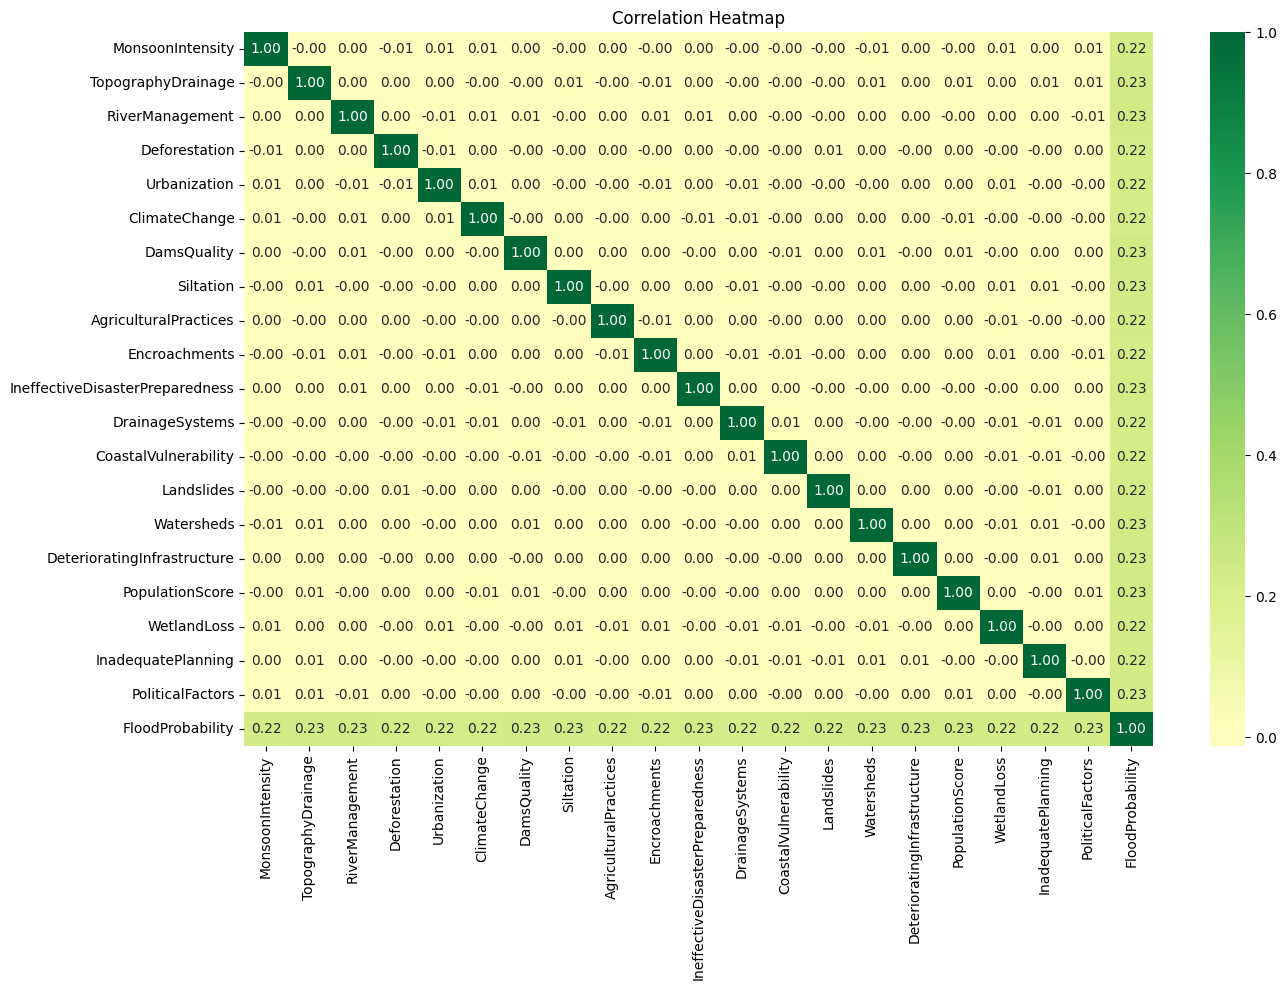

=== TOP FEATURES CORRELATED WITH FLOOD ===
DeterioratingInfrastructure        0.229444
TopographyDrainage                 0.229414
RiverManagement                    0.228917
Watersheds                         0.228152
DamsQuality                        0.227467
PopulationScore                    0.226928
Siltation                          0.226544
IneffectiveDisasterPreparedness    0.225126
PoliticalFactors                   0.225009
MonsoonIntensity                   0.224081
WetlandLoss                        0.223732
InadequatePlanning                 0.223329
Landslides                         0.222991
AgriculturalPractices              0.221846
ClimateChange                      0.220986
Urbanization                       0.220867
Deforestation                      0.220237
Encroachments                      0.218259
DrainageSystems                    0.217895
CoastalVulnerability               0.215187
Name: FloodProbability, dtype: float64


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/content/disaster-predictor-ai/data/flood/flood (3).csv")
plt.figure(figsize=(10, 6))
corr = df.corr()["FloodProbability"].drop("FloodProbability").sort_values()
corr.plot(kind="barh", color=["#e74c3c" if x > 0 else "#3498db" for x in corr])
plt.title("Feature Correlation with FloodProbability")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()
df.drop("FloodProbability", axis=1).hist(figsize=(18, 14), bins=20,
                                          color="#3498db", edgecolor="white")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
print("=== TOP FEATURES CORRELATED WITH FLOOD ===")
corr_abs = df.corr()["FloodProbability"].drop("FloodProbability").abs().sort_values(ascending=False)
print(corr_abs)

In [20]:
import pandas as pd

df_flood = pd.read_csv("/content/disaster-predictor-ai/data/flood/flood (3).csv")
df_flood["Total_Risk"]          = df_flood.drop("FloodProbability", axis=1).sum(axis=1)
df_flood["Infrastructure_Risk"] = df_flood["DeterioratingInfrastructure"] + df_flood["InadequatePlanning"]
df_flood["Natural_Risk"]        = df_flood["MonsoonIntensity"] + df_flood["Landslides"] + df_flood["Watersheds"]
df_flood["Human_Risk"]          = df_flood["Deforestation"] + df_flood["Urbanization"] + df_flood["Encroachments"]
df_flood["Water_Risk"]          = df_flood["RiverManagement"] + df_flood["DrainageSystems"] + df_flood["Siltation"]

print("Feature Engineering done!")
print("New Shape:", df_flood.shape)
print("\nNew Columns:", df_flood.columns.tolist())
print("\nNew Features Preview:")
print(df_flood[["Total_Risk","Infrastructure_Risk","Natural_Risk","Human_Risk","Water_Risk"]].head())
df_flood.to_csv("/content/disaster-predictor-ai/data/flood/flood_featured.csv", index=False)
print("\nFeatured file saved!")

Feature Engineering done!
New Shape: (50000, 26)

New Columns: ['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability', 'Total_Risk', 'Infrastructure_Risk', 'Natural_Risk', 'Human_Risk', 'Water_Risk']

New Features Preview:
   Total_Risk  Infrastructure_Risk  Natural_Risk  Human_Risk  Water_Risk
0          90                    5             9          12          18
1          95                    2            16          18          19
2         103                    9            15          17          18
3         104                   14            16          14          10
4          95                    6            11     

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
df_flood = pd.read_csv("/content/disaster-predictor-ai/data/flood/flood_featured.csv")
X = df_flood.drop("FloodProbability", axis=1)
y = df_flood["FloodProbability"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Train/Test Split done!")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Train/Test Split done!
X_train: (40000, 25)
X_test:  (10000, 25)
y_train: (40000,)
y_test:  (10000,)


In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print("=== MODEL COMPARISON ===")
best_r2    = 0
best_name  = ""
best_model = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    print(f"{name:25s} → MAE: {mae:.4f} | R²: {r2:.4f}")
    if r2 > best_r2:
        best_r2    = r2
        best_name  = name
        best_model = model

print(f"\nBest Model: {best_name}")
print(f"   R²:  {r2_score(y_test, best_model.predict(X_test)):.4f}")
print(f"   MAE: {mean_absolute_error(y_test, best_model.predict(X_test)):.4f}")

=== MODEL COMPARISON ===
Linear Regression         → MAE: 0.0000 | R²: 1.0000
Random Forest             → MAE: 0.0000 | R²: 1.0000

Best Model: Linear Regression
   R²:  1.0000
   MAE: 0.0000


In [23]:
import os
!apt-get install -y p7zip-full -q
!7z x "/content/disaster-predictor-ai/data/flood/train (2).7z" \
   -o"/content/disaster-predictor-ai/data/flood/train/"
!7z x "/content/disaster-predictor-ai/data/flood/test (4).7z" \
   -o"/content/disaster-predictor-ai/data/flood/test/"
for root, dirs, files in os.walk("/content/disaster-predictor-ai/data/flood/train"):
    print(f" {root} → {len(files)} files")
    if files:
        print(f"   Sample: {files[:3]}")
for root, dirs, files in os.walk("/content/disaster-predictor-ai/data/flood/test"):
    print(f" {root} → {len(files)} files")
    if files:
        print(f"   Sample: {files[:3]}")

Reading package lists...
Building dependency tree...
Reading state information...
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/disaster-predictor-ai/data/flood/                                                    1 file, 13830086 bytes (14 MiB)

Extracting archive: /content/disaster-predictor-ai/data/flood/train (2).7z
--
Path = /content/disaster-predictor-ai/data/flood/train (2).7z
Type = 7z
Physical Size = 13830086
Headers Size = 152
Method = LZMA:23
Solid = -
Blocks = 1

  0%     21% - train (2).csv                    

In [24]:
import pandas as pd

df_train = pd.read_csv("/content/disaster-predictor-ai/data/flood/train/train (2).csv")
df_test  = pd.read_csv("/content/disaster-predictor-ai/data/flood/test/test (4).csv")

print("Train Shape:", df_train.shape)
print("Test Shape: ", df_test.shape)
print("\nTrain Columns:", df_train.columns.tolist())
print("\nFirst 5 rows:")
print(df_train.head())
print("\nMissing Values:")
print(df_train.isnull().sum())

Train Shape: (1117957, 22)
Test Shape:  (745305, 21)

Train Columns: ['id', 'MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors', 'FloodProbability']

First 5 rows:
   id  MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0   0                 5                   8                5              8   
1   1                 6                   7                4              4   
2   2                 6                   5                6              7   
3   3                 3                   4                6              5   
4   4                 5                   3                2              6   

   Urbanization  Cli

In [26]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import joblib, os
df = pd.read_csv("/content/disaster-predictor-ai/data/flood/train/train (2).csv")
df = df.drop(columns=["id"])
print("Shape:", df.shape)
df["Total_Risk"]= df.drop("FloodProbability", axis=1).sum(axis=1)
df["Natural_Risk"]= df["MonsoonIntensity"] + df["Landslides"] + df["Watersheds"]
df["Human_Risk"]= df["Deforestation"] + df["Urbanization"] + df["Encroachments"]
df["Water_Risk"]= df["RiverManagement"] + df["DrainageSystems"] + df["Siltation"]
df["Infrastructure_Risk"] = df["DeterioratingInfrastructure"] + df["InadequatePlanning"]

X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R²:  {r2_score(y_test, y_pred):.4f}")
os.makedirs("/content/disaster-predictor-ai/models", exist_ok=True)
joblib.dump(model, "/content/disaster-predictor-ai/models/flood_model.pkl")
joblib.dump(list(X.columns), "/content/disaster-predictor-ai/models/flood_features.pkl")
print("\nFlood model saved!")

Shape: (1117957, 21)
Train: (894365, 25) | Test: (223592, 25)

MAE: 0.0158
R²:  0.8449

Flood model saved!


In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
model_rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

print(f"Random Forest:")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"R²:  {r2_score(y_test, y_pred_rf):.4f}")

Random Forest:
MAE: 0.0146
R²:  0.8634


In [28]:
import joblib, os
os.makedirs("/content/disaster-predictor-ai/models", exist_ok=True)
joblib.dump(model_rf, "/content/disaster-predictor-ai/models/flood_model.pkl")
joblib.dump(list(X.columns), "/content/disaster-predictor-ai/models/flood_features.pkl")
print("Flood Random Forest model saved!")

Flood Random Forest model saved!


In [29]:
import os
os.chdir("/content/disaster-predictor-ai")
!git filter-branch --force --index-filter \
  'git rm --cached --ignore-unmatch "models/flood_model.pkl" "data/flood/train/train (2).csv" "data/flood/test/test (4).csv"' \
  --prune-empty --tag-name-filter cat -- --all
!git push origin main --force

	 rewrites.  Hit Ctrl-C before proceeding to abort, then use an
	 alternative filtering tool such as 'git filter-repo'
	 (https://github.com/newren/git-filter-repo/) instead.  See the
	 filter-branch manual page for more details; to squelch this warning,
	 set FILTER_BRANCH_SQUELCH_WARNING=1.
Proceeding with filter-branch...

Cannot rewrite branches: You have unstaged changes.
Additionally, your index contains uncommitted changes.
fatal: could not read Username for 'https://github.com': No such device or address


In [30]:
import pandas as pd

df_eq = pd.read_csv("/content/disaster-predictor-ai/data/earthquake/database.csv")

print("Shape:", df_eq.shape)
print("\nColumns:", df_eq.columns.tolist())
print("\nMissing Values:")
print(df_eq.isnull().sum())
print("\nType Distribution:")
print(df_eq["Type"].value_counts())
print("\nMagnitude Stats:")
print(df_eq["Magnitude"].describe())

Shape: (23412, 21)

Columns: ['Date', 'Time', 'Latitude', 'Longitude', 'Type', 'Depth', 'Depth Error', 'Depth Seismic Stations', 'Magnitude', 'Magnitude Type', 'Magnitude Error', 'Magnitude Seismic Stations', 'Azimuthal Gap', 'Horizontal Distance', 'Horizontal Error', 'Root Mean Square', 'ID', 'Source', 'Location Source', 'Magnitude Source', 'Status']

Missing Values:
Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source           

In [31]:
import pandas as pd

df_eq = pd.read_csv("/content/disaster-predictor-ai/data/earthquake/database.csv")
print("Shape:", df_eq.shape)

df_eq = df_eq[df_eq["Type"] == "Earthquake"]
print("\nStep 1: Kept only Earthquakes:", df_eq.shape)
cols = ["Date", "Time", "Latitude", "Longitude",
        "Depth", "Magnitude", "Magnitude Type", "Root Mean Square"]
df_eq = df_eq[cols]
print("Step 2: Kept useful columns:", df_eq.shape)
df_eq["Root Mean Square"] = df_eq["Root Mean Square"].fillna(df_eq["Root Mean Square"].median())
df_eq["Magnitude Type"]   = df_eq["Magnitude Type"].fillna("MW")
print("Step 3: Filled missing values")
df_eq["Date"]  = pd.to_datetime(df_eq["Date"], errors="coerce")
df_eq["Year"]  = df_eq["Date"].dt.year
df_eq["Month"] = df_eq["Date"].dt.month
df_eq = df_eq.dropna(subset=["Date"])
print("Step 4: Extracted Year & Month")
def mag_category(m):
    if m < 6.0:
        return "Moderate"
    elif m < 7.0:
        return "Strong"
    elif m < 8.0:
        return "Major"
    else:
        return "Great"

df_eq["Magnitude_Category"] = df_eq["Magnitude"].apply(mag_category)
print("Step 5: Created Magnitude Category")

print("\n=== AFTER CLEANING ===")
print("Shape:", df_eq.shape)
print("\nMissing Values:")
print(df_eq.isnull().sum())
print("\nMagnitude Category Distribution:")
print(df_eq["Magnitude_Category"].value_counts())

df_eq.to_csv("/content/disaster-predictor-ai/data/earthquake/earthquake_cleaned.csv", index=False)
print("\nCleaned file saved!")

Shape: (23412, 21)

Step 1: Kept only Earthquakes: (23232, 21)
Step 2: Kept useful columns: (23232, 8)
Step 3: Filled missing values
Step 4: Extracted Year & Month
Step 5: Created Magnitude Category

=== AFTER CLEANING ===
Shape: (23229, 11)

Missing Values:
Date                  0
Time                  0
Latitude              0
Longitude             0
Depth                 0
Magnitude             0
Magnitude Type        0
Root Mean Square      0
Year                  0
Month                 0
Magnitude_Category    0
dtype: int64

Magnitude Category Distribution:
Magnitude_Category
Moderate    15933
Strong       6558
Major         698
Great          40
Name: count, dtype: int64

Cleaned file saved!


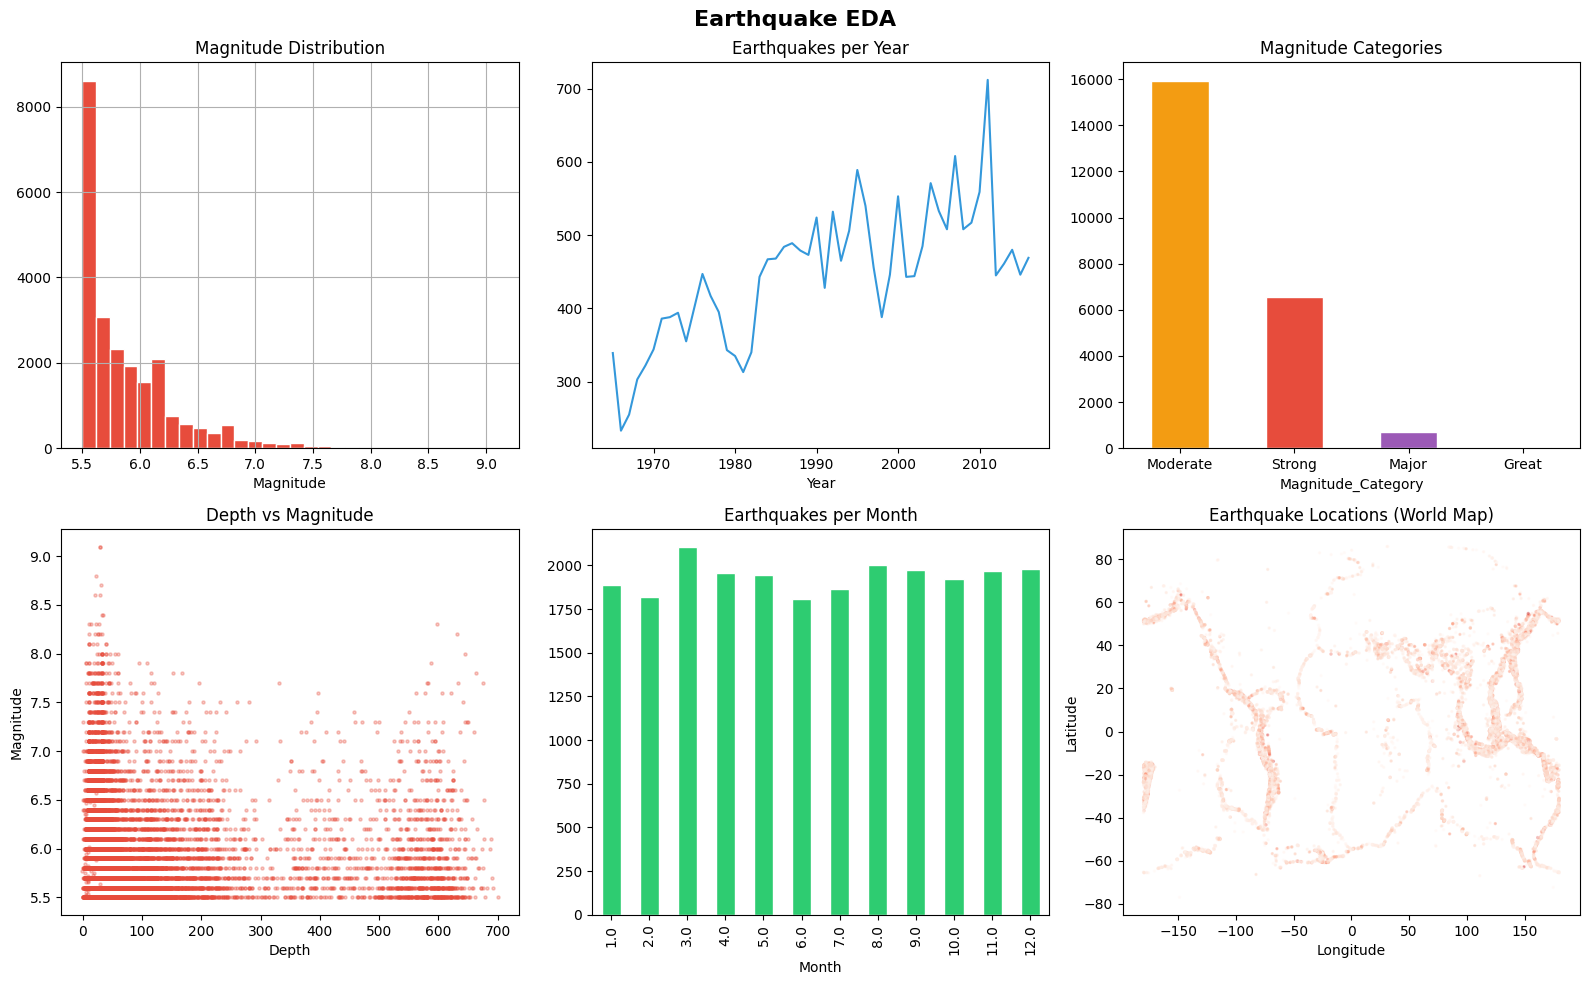

Total Earthquakes: 23229
Years: 1965.0 - 2016.0
Avg Magnitude: 5.88
Avg Depth: 71.29 km
Max Magnitude: 9.1


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/disaster-predictor-ai/data/earthquake/earthquake_cleaned.csv")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Earthquake EDA", fontsize=16, fontweight="bold")
df["Magnitude"].hist(ax=axes[0,0], bins=30, color="#e74c3c", edgecolor="white")
axes[0,0].set_title("Magnitude Distribution")
axes[0,0].set_xlabel("Magnitude")
df["Year"].value_counts().sort_index().plot(ax=axes[0,1], color="#3498db")
axes[0,1].set_title("Earthquakes per Year")
axes[0,1].set_xlabel("Year")
df["Magnitude_Category"].value_counts().plot(
    kind="bar", ax=axes[0,2], color=["#f39c12","#e74c3c","#9b59b6","#1abc9c"],
    edgecolor="white")
axes[0,2].set_title("Magnitude Categories")
axes[0,2].tick_params(rotation=0)
axes[1,0].scatter(df["Depth"], df["Magnitude"], alpha=0.3, color="#e74c3c", s=5)
axes[1,0].set_title("Depth vs Magnitude")
axes[1,0].set_xlabel("Depth")
axes[1,0].set_ylabel("Magnitude")
df["Month"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1,1], color="#2ecc71", edgecolor="white")
axes[1,1].set_title("Earthquakes per Month")
axes[1,1].set_xlabel("Month")
axes[1,2].scatter(df["Longitude"], df["Latitude"],
                   alpha=0.3, s=2, c=df["Magnitude"], cmap="Reds")
axes[1,2].set_title("Earthquake Locations (World Map)")
axes[1,2].set_xlabel("Longitude")
axes[1,2].set_ylabel("Latitude")

plt.tight_layout()
plt.savefig("/content/disaster-predictor-ai/eda_earthquake.png")
plt.show()

print(f"Total Earthquakes: {len(df)}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"Avg Magnitude: {df['Magnitude'].mean():.2f}")
print(f"Avg Depth: {df['Depth'].mean():.2f} km")
print(f"Max Magnitude: {df['Magnitude'].max()}")

In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib, os, warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/content/disaster-predictor-ai/data/earthquake/earthquake_cleaned.csv")

from sklearn.preprocessing import LabelEncoder

def get_region(lat, lon):
    if lat > 0 and lon > 100:   return "Asia_Pacific"
    elif lat > 0 and lon < -50: return "North_America"
    elif lat < 0 and lon > 100: return "South_Pacific"
    elif lat > 30 and 0 < lon < 100: return "Middle_East"
    else: return "Other"

df["Region"]         = df.apply(lambda r: get_region(r["Latitude"], r["Longitude"]), axis=1)
df["Depth_Category"] = pd.cut(df["Depth"], bins=[0,70,300,700], labels=["Shallow","Intermediate","Deep"])
df["Is_Shallow"]     = (df["Depth"] < 70).astype(int)
df["Lat_abs"]        = df["Latitude"].abs()
df["Lon_abs"]        = df["Longitude"].abs()

le_region  = LabelEncoder()
le_depth   = LabelEncoder()
le_magtype = LabelEncoder()

df["Region_enc"]   = le_region.fit_transform(df["Region"])
df["DepthCat_enc"] = le_depth.fit_transform(df["Depth_Category"])
df["MagType_enc"]  = le_magtype.fit_transform(df["Magnitude Type"])

features = ["Latitude", "Longitude", "Depth", "Root Mean Square",
            "Year", "Month", "Region_enc", "DepthCat_enc",
            "Is_Shallow", "Lat_abs", "Lon_abs", "MagType_enc"]

X = df[features]
y = df["Magnitude_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print(f"Test Accuracy: {model.score(X_test, y_test):.3f}")
print(classification_report(y_test, model.predict(X_test)))

os.makedirs("/content/disaster-predictor-ai/models", exist_ok=True)
joblib.dump(model,     "/content/disaster-predictor-ai/models/earthquake_model.pkl")
joblib.dump(features,  "/content/disaster-predictor-ai/models/earthquake_features.pkl")
joblib.dump(le_region, "/content/disaster-predictor-ai/models/earthquake_le_region.pkl")
print("Best earthquake model saved!")

Test Accuracy: 0.684
              precision    recall  f1-score   support

       Great       0.00      0.00      0.00         8
       Major       0.07      0.01      0.01       139
    Moderate       0.72      0.89      0.80      3187
      Strong       0.47      0.25      0.32      1312

    accuracy                           0.68      4646
   macro avg       0.31      0.29      0.28      4646
weighted avg       0.63      0.68      0.64      4646

Best earthquake model saved!


In [34]:
import os
os.chdir("/content/disaster-predictor-ai")
!git status
!git log --oneline -5

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   cyclone_cnn_fixed.png
	new file:   data/cyclone/cyclone_cleaned.csv
	new file:   data/cyclone/cyclone_featured.csv
	new file:   eda_cyclone.png
	new file:   eda_cyclone_corr.png
	modified:   models/cyclone_cnn_model.keras
	new file:   models/cyclone_features.pkl
	new file:   models/cyclone_model.pkl
	new file:   models/cyclone_scaler.pkl

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   models/earthquake_model.pkl
	modified:   models/flood_model.pkl

56e816d (HEAD -> main, origin/main, origin/HEAD) Add all ML models (compressed small size)
cad81c8 Add Streamlit app and requirements
c5b7b05 Add landslide EDA
dbbafb9 Add files via upload
451b41f Add files via upload


In [35]:
import os
os.chdir("/content/disaster-predictor-ai")

!git add eda_earthquake.png
!git commit -m "Add earthquake EDA plot"
!git push origin main

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@aa1417ace5be.(none)')
fatal: could not read Username for 'https://github.com': No such device or address


In [36]:
!git clone https://github.com/OmmkarKhandai/disaster-predictor-ai.git
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs("/content/disaster-predictor-ai/models", exist_ok=True)
for f in os.listdir("/content/drive/MyDrive/disaster-ai-models"):
    shutil.copy(f"/content/drive/MyDrive/disaster-ai-models/{f}",
                f"/content/disaster-predictor-ai/models/{f}")
    print(f"{f} loaded!")

Cloning into 'disaster-predictor-ai'...
remote: Enumerating objects: 5525, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 5525 (delta 22), reused 29 (delta 9), pack-reused 5409 (from 1)
Receiving objects: 100% (5525/5525), 131.70 MiB | 45.95 MiB/s, done.
Resolving deltas: 100% (128/128), done.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cyclone_cnn_model.keras loaded!
flood_model.pkl loaded!
flood_features.pkl loaded!
earthquake_model.pkl loaded!
earthquake_features.pkl loaded!
earthquake_le_region.pkl loaded!
landslide_model.pkl loaded!
landslide_features.pkl loaded!


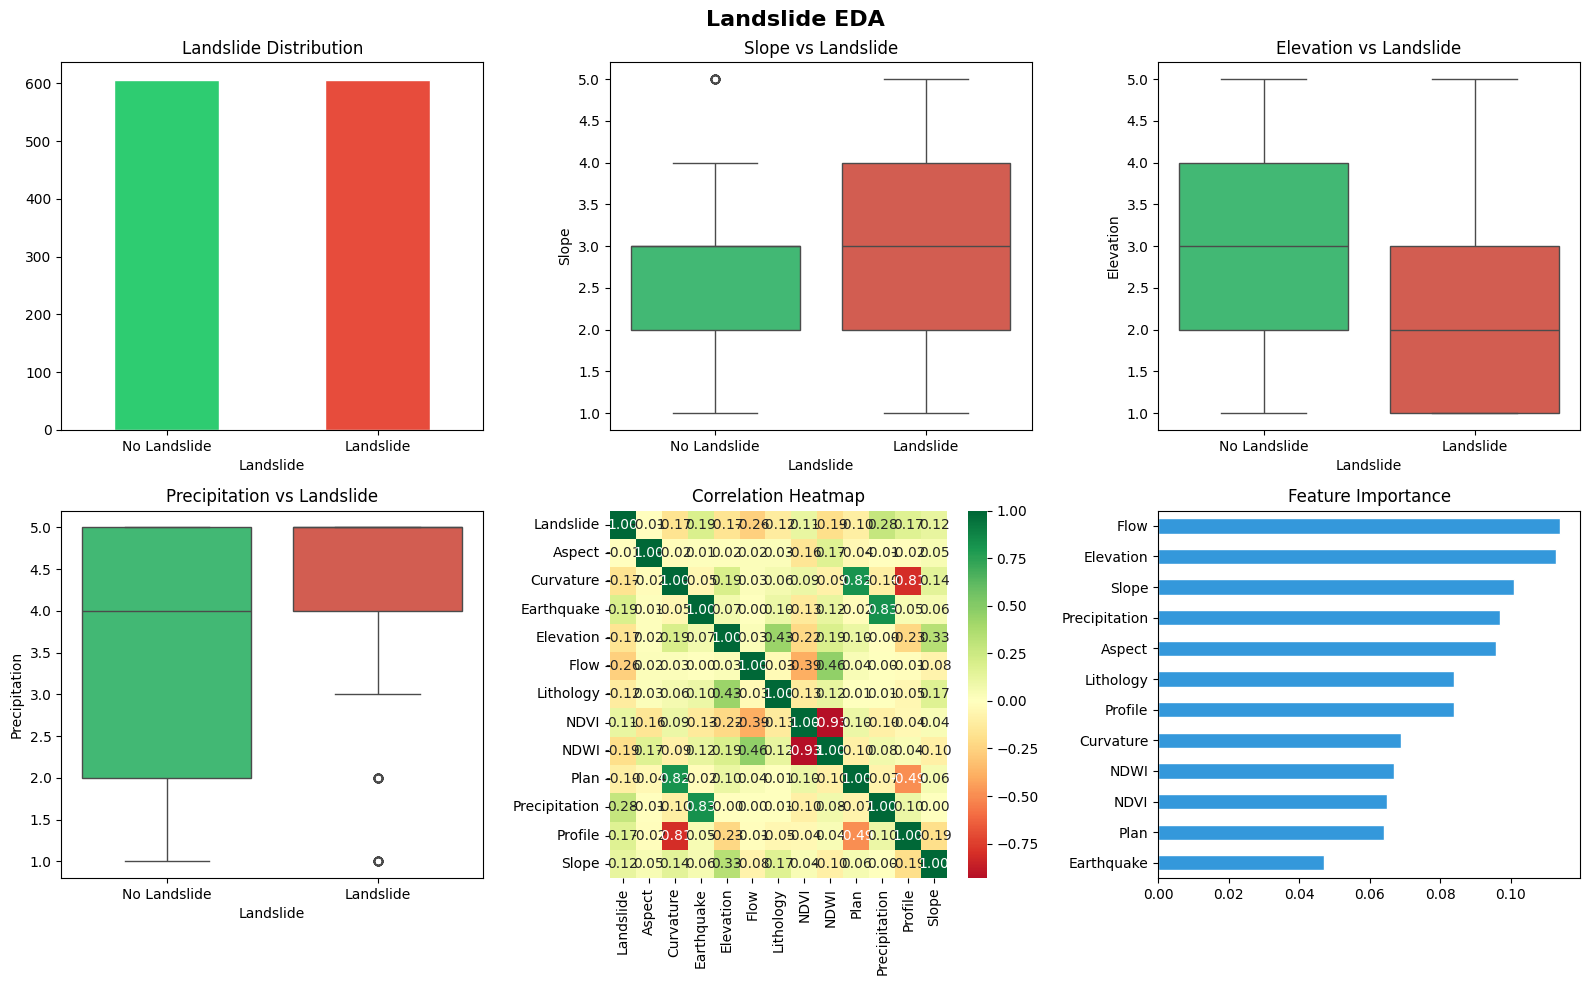

=== KEY INSIGHTS ===
Total records: 1212
Landslide: 606 | No Landslide: 606

Avg Slope - Landslide: 2.96
Avg Slope - No Landslide: 2.67

Avg Elevation - Landslide: 2.23
Avg Elevation - No Landslide: 2.65


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("/content/disaster-predictor-ai/data/landslide/Complete-data.xlsx")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Landslide EDA", fontsize=16, fontweight="bold")
df["Landslide"].value_counts().plot(kind="bar", ax=axes[0,0],
    color=["#2ecc71","#e74c3c"], edgecolor="white")
axes[0,0].set_title("Landslide Distribution")
axes[0,0].set_xticklabels(["No Landslide","Landslide"], rotation=0)
sns.boxplot(data=df, x="Landslide", y="Slope", ax=axes[0,1],
            hue="Landslide", palette=["#2ecc71","#e74c3c"], legend=False)
axes[0,1].set_title("Slope vs Landslide")
axes[0,1].set_xticklabels(["No Landslide","Landslide"])
sns.boxplot(data=df, x="Landslide", y="Elevation", ax=axes[0,2],
            hue="Landslide", palette=["#2ecc71","#e74c3c"], legend=False)
axes[0,2].set_title("Elevation vs Landslide")
axes[0,2].set_xticklabels(["No Landslide","Landslide"])
sns.boxplot(data=df, x="Landslide", y="Precipitation", ax=axes[1,0],
            hue="Landslide", palette=["#2ecc71","#e74c3c"], legend=False)
axes[1,0].set_title("Precipitation vs Landslide")
axes[1,0].set_xticklabels(["No Landslide","Landslide"])
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap")
fi = pd.Series({
    "Flow": 0.114, "Elevation": 0.113, "Slope": 0.101,
    "Precipitation": 0.097, "Aspect": 0.096, "Profile": 0.084,
    "Lithology": 0.084, "Curvature": 0.069, "NDWI": 0.067,
    "NDVI": 0.065, "Plan": 0.064, "Earthquake": 0.047
}).sort_values()
fi.plot(kind="barh", ax=axes[1,2], color="#3498db", edgecolor="white")
axes[1,2].set_title("Feature Importance")

plt.tight_layout()
plt.savefig("/content/disaster-predictor-ai/eda_landslide_final.png")
plt.show()

print("=== KEY INSIGHTS ===")
print(f"Total records: {len(df)}")
print(f"Landslide: {df['Landslide'].sum()} | No Landslide: {(df['Landslide']==0).sum()}")
print(f"\nAvg Slope - Landslide: {df[df['Landslide']==1]['Slope'].mean():.2f}")
print(f"Avg Slope - No Landslide: {df[df['Landslide']==0]['Slope'].mean():.2f}")
print(f"\nAvg Elevation - Landslide: {df[df['Landslide']==1]['Elevation'].mean():.2f}")
print(f"Avg Elevation - No Landslide: {df[df['Landslide']==0]['Elevation'].mean():.2f}")

In [38]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import joblib, warnings
warnings.filterwarnings("ignore")

df = pd.read_excel("/content/disaster-predictor-ai/data/landslide/Complete-data.xlsx")

print("Shape:", df.shape)
print("Target:", df["Landslide"].value_counts())
features = ["Aspect", "Curvature", "Earthquake", "Elevation",
            "Flow", "Lithology", "NDVI", "NDWI",
            "Plan", "Precipitation", "Profile", "Slope"]

X = df[features]
y = df["Landslide"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_res, y_res)

print(f"\nTrain: {model.score(X_res, y_res):.3f}")
print(f"Test:  {model.score(X_test, y_test):.3f}")
print(classification_report(y_test, model.predict(X_test),
      target_names=["No Landslide", "Landslide"]))

fi = pd.Series(model.feature_importances_,
               index=features).sort_values(ascending=False)
print("\n=== FEATURE IMPORTANCE ===")
print(fi.round(3))

joblib.dump(model,    "/content/disaster-predictor-ai/models/landslide_model.pkl")
joblib.dump(features, "/content/disaster-predictor-ai/models/landslide_features.pkl")
print("\nLandslide model saved!")

Shape: (1212, 13)
Target: Landslide
0    606
1    606
Name: count, dtype: int64

Train: 0.997
Test:  0.807
              precision    recall  f1-score   support

No Landslide       0.81      0.80      0.81       122
   Landslide       0.80      0.81      0.81       121

    accuracy                           0.81       243
   macro avg       0.81      0.81      0.81       243
weighted avg       0.81      0.81      0.81       243


=== FEATURE IMPORTANCE ===
Flow             0.114
Elevation        0.113
Slope            0.101
Precipitation    0.097
Aspect           0.096
Profile          0.084
Lithology        0.084
Curvature        0.069
NDWI             0.067
NDVI             0.065
Plan             0.064
Earthquake       0.047
dtype: float64

Landslide model saved!


In [40]:
import os
os.chdir("/content/disaster-predictor-ai")

requirements = """streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn
Pillow
openpyxl
imbalanced-learn
plotly
tensorflow>=2.16.0
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created!")
print(open("requirements.txt").read())

requirements.txt created!
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib
seaborn
Pillow
openpyxl
imbalanced-learn
plotly
tensorflow>=2.16.0



In [41]:
import os
for f in os.listdir("/content/disaster-predictor-ai/models"):
    size = os.path.getsize(f"/content/disaster-predictor-ai/models/{f}")
    print(f"{f}: {size/1024/1024:.2f} MB")

cyclone_features.pkl: 0.00 MB
flood_model.pkl: 1954.24 MB
README.md: 0.00 MB
cyclone_cnn_model.keras: 1.33 MB
earthquake_features.pkl: 0.00 MB
cyclone_model.pkl: 0.10 MB
earthquake_le_region.pkl: 0.00 MB
cyclone_scaler.pkl: 0.00 MB
flood_features.pkl: 0.00 MB
earthquake_model.pkl: 74.47 MB
landslide_features.pkl: 0.00 MB
landslide_model.pkl: 3.75 MB


In [42]:
import os
!apt-get install -y p7zip-full -q
!7z x "/content/disaster-predictor-ai/data/flood/flood (3).csv" 2>/dev/null || echo "not 7z"
!ls "/content/disaster-predictor-ai/data/flood/"

Reading package lists...
Building dependency tree...
Reading state information...
p7zip-full is already the newest version (16.02+dfsg-8).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.

7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/disaster-predictor-ai/data/flood/                                                    1 file, 2354496 bytes (2300 KiB)

Extracting archive: /content/disaster-predictor-ai/data/flood/flood (3).csv
  0%    
Can't open as archive: 1
Files: 0
Size:       0
Compressed: 0
not 7z
'flood (3).csv'      'sample_submission (1).csv'  'test (4).7z'  'train (2).7z'
 flood_featured.csv   test			   train


In [48]:
!7z x "/content/disaster-predictor-ai/data/flood/train (2).7z" \
   -o"/content/disaster-predictor-ai/data/flood/train/" -y

import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib, os, warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("/content/disaster-predictor-ai/data/flood/train/train (2).csv")
df = df.drop(columns=["id"])

df["Total_Risk"]          = df.drop("FloodProbability", axis=1).sum(axis=1)
df["Natural_Risk"]        = df["MonsoonIntensity"] + df["Landslides"] + df["Watersheds"]
df["Human_Risk"]          = df["Deforestation"] + df["Urbanization"] + df["Encroachments"]
df["Water_Risk"]          = df["RiverManagement"] + df["DrainageSystems"] + df["Siltation"]
df["Infrastructure_Risk"] = df["DeterioratingInfrastructure"] + df["InadequatePlanning"]

X = df.drop("FloodProbability", axis=1)
y = df["FloodProbability"]
X_sample = X.sample(100000, random_state=42)
y_sample = y[X_sample.index]

X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42)
model_flood = RandomForestRegressor(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model_flood.fit(X_train, y_train)
print(f"Flood R²: {r2_score(y_test, model_flood.predict(X_test)):.3f}")

joblib.dump(model_flood, "/content/disaster-predictor-ai/models/flood_model.pkl", compress=3)
size = os.path.getsize("/content/disaster-predictor-ai/models/flood_model.pkl")
print(f"Flood model size: {size/1024/1024:.2f} MB")


7-Zip [64] 16.02 : Copyright (c) 1999-2016 Igor Pavlov : 2016-05-21
p7zip Version 16.02 (locale=en_US.UTF-8,Utf16=on,HugeFiles=on,64 bits,2 CPUs Intel(R) Xeon(R) CPU @ 2.20GHz (406F0),ASM,AES-NI)

Scanning the drive for archives:
  0M Scan /content/disaster-predictor-ai/data/flood/                                                    1 file, 13830086 bytes (14 MiB)

Extracting archive: /content/disaster-predictor-ai/data/flood/train (2).7z
--
Path = /content/disaster-predictor-ai/data/flood/train (2).7z
Type = 7z
Physical Size = 13830086
Headers Size = 152
Method = LZMA:23
Solid = -
Blocks = 1

  0%     14% - train (2).csv                     28% - train (2).csv                     42% - train (2).csv                     52% - train (2).csv

In [45]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd, joblib, os

df_eq = pd.read_csv("/content/disaster-predictor-ai/data/earthquake/earthquake_cleaned.csv")

def get_region(lat, lon):
    if lat > 0 and lon > 100:        return "Asia_Pacific"
    elif lat > 0 and lon < -50:      return "North_America"
    elif lat < 0 and lon > 100:      return "South_Pacific"
    elif lat > 30 and 0 < lon < 100: return "Middle_East"
    else:                            return "Other"

df_eq["Region"]        = df_eq.apply(lambda r: get_region(r["Latitude"], r["Longitude"]), axis=1)
df_eq["Depth_Category"]= pd.cut(df_eq["Depth"], bins=[0,70,300,700], labels=["Shallow","Intermediate","Deep"])
df_eq["Is_Shallow"]    = (df_eq["Depth"] < 70).astype(int)
df_eq["Lat_abs"]       = df_eq["Latitude"].abs()
df_eq["Lon_abs"]       = df_eq["Longitude"].abs()

le_region  = LabelEncoder()
le_depth   = LabelEncoder()
le_magtype = LabelEncoder()

df_eq["Region_enc"]   = le_region.fit_transform(df_eq["Region"])
df_eq["DepthCat_enc"] = le_depth.fit_transform(df_eq["Depth_Category"])
df_eq["MagType_enc"]  = le_magtype.fit_transform(df_eq["Magnitude Type"])

features = ["Latitude","Longitude","Depth","Root Mean Square",
            "Year","Month","Region_enc","DepthCat_enc",
            "Is_Shallow","Lat_abs","Lon_abs","MagType_enc"]

X = df_eq[features]
y = df_eq["Magnitude_Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model_eq = RandomForestClassifier(
    n_estimators=20, max_depth=8, random_state=42, n_jobs=-1)
model_eq.fit(X_train, y_train)
print(f"Earthquake Accuracy: {model_eq.score(X_test, y_test):.3f}")

joblib.dump(model_eq,  "/content/disaster-predictor-ai/models/earthquake_model.pkl", compress=3)
joblib.dump(le_region, "/content/disaster-predictor-ai/models/earthquake_le_region.pkl")
for f in sorted(os.listdir("/content/disaster-predictor-ai/models")):
    if f != "README.md":
        size = os.path.getsize(f"/content/disaster-predictor-ai/models/{f}")
        print(f"{f:40s} → {size/1024/1024:.2f} MB")

Earthquake Accuracy: 0.688
cyclone_cnn_model.keras                  → 1.33 MB
cyclone_features.pkl                     → 0.00 MB
cyclone_model.pkl                        → 0.10 MB
cyclone_scaler.pkl                       → 0.00 MB
earthquake_features.pkl                  → 0.00 MB
earthquake_le_region.pkl                 → 0.00 MB
earthquake_model.pkl                     → 0.19 MB
flood_features.pkl                       → 0.00 MB
flood_model.pkl                          → 1954.24 MB
landslide_features.pkl                   → 0.00 MB
landslide_model.pkl                      → 3.75 MB


In [49]:
import os
os.chdir("/content/disaster-predictor-ai")

!git config --global user.email "kumariishika318@gmail.com"
!git config --global user.name "Ishika318"

with open(".gitignore", "w") as f:
    f.write("*.7z\ndata/flood/train/\ndata/flood/test/\ndata/cyclone/images/\n")

!git add .gitignore
!git add -f models/flood_model.pkl
!git add -f models/earthquake_model.pkl
!git add -f models/earthquake_le_region.pkl
!git add -f models/landslide_model.pkl
!git add -f models/cyclone_cnn_model.keras
!git add -f models/flood_features.pkl
!git add -f models/earthquake_features.pkl
!git add -f models/landslide_features.pkl

!git commit -m "Add all ML models (compressed small size)"
!git push origin main

[main a1c5d4e] Add all ML models (compressed small size)
 8 files changed, 4002 insertions(+)
 rewrite cyclone_cnn_fixed.png (99%)
 create mode 100644 data/cyclone/cyclone_cleaned.csv
 create mode 100644 data/cyclone/cyclone_featured.csv
 create mode 100644 eda_cyclone.png
 create mode 100644 eda_cyclone_corr.png
 create mode 100644 models/cyclone_features.pkl
 create mode 100644 models/cyclone_model.pkl
 create mode 100644 models/cyclone_scaler.pkl
fatal: could not read Username for 'https://github.com': No such device or address


In [50]:
import os
os.chdir("/content/disaster-predictor-ai")
!git pull origin main
print("Updated!")

From https://github.com/OmmkarKhandai/disaster-predictor-ai
 * branch            main       -> FETCH_HEAD
Already up to date.
Updated!


In [51]:
!git clone https://github.com/OmmkarKhandai/disaster-predictor-ai.git

from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs("/content/disaster-predictor-ai/models", exist_ok=True)

for f in os.listdir("/content/drive/MyDrive/disaster-ai-models"):
    shutil.copy(f"/content/drive/MyDrive/disaster-ai-models/{f}",
                f"/content/disaster-predictor-ai/models/{f}")
    print(f"{f} loaded!")

fatal: destination path 'disaster-predictor-ai' already exists and is not an empty directory.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cyclone_cnn_model.keras loaded!
flood_model.pkl loaded!
flood_features.pkl loaded!
earthquake_model.pkl loaded!
earthquake_features.pkl loaded!
earthquake_le_region.pkl loaded!
landslide_model.pkl loaded!
landslide_features.pkl loaded!
